# 04 — System B External Validation

## 1. Objective

This notebook performs locked external validation of the three frozen
Health System A prediction pipelines in Health System B.

The prediction task remains unchanged:

- **Landmark:** ICU hour 6
- **Prediction window:** ICU hours 6–18
- **Outcome:** incident sepsis onset during `(6, 18]`
- **Frozen predictors:** 84 engineered model columns
- **Development system:** Health System A
- **External validation system:** Health System B

The following decisions are already frozen and are not modified using
System B:

- cohort eligibility;
- outcome reconstruction;
- feature definitions;
- physiologic plausibility rules;
- missingness representation;
- preprocessing strategy;
- model classes;
- hyperparameters.

The three frozen models are:

1. Ridge logistic regression;
2. Elastic-Net logistic regression;
3. LightGBM.

System B is used only for external evaluation.

## 2. Load Frozen Development Artifacts and System B Data

The serialized System A models and model specification are loaded before
constructing the System B evaluation cohort.

The exact predictor ordering stored during System A model development is
retained.

In [1]:
from pathlib import Path
import json

import joblib
import numpy as np
import pandas as pd


ROOT = Path.cwd()

if not (ROOT / "data").exists():
    ROOT = ROOT.parent


# ---------------------------------------------------------
# System B raw data
# ---------------------------------------------------------

B_DIR = (
    ROOT
    / "data"
    / "raw"
    / "training"
    / "training_setB"
)

files_b = sorted(
    B_DIR.glob("*.psv")
)


# ---------------------------------------------------------
# Frozen System A artifacts
# ---------------------------------------------------------

FROZEN_DIR = (
    ROOT
    / "results"
    / "frozen"
)

MODEL_DIR = (
    FROZEN_DIR
    / "models"
)

METADATA_DIR = (
    FROZEN_DIR
    / "metadata"
)

RIDGE_MODEL_PATH = (
    MODEL_DIR
    / "ridge_system_a.joblib"
)

ELASTIC_NET_MODEL_PATH = (
    MODEL_DIR
    / "elastic_net_system_a.joblib"
)

LIGHTGBM_MODEL_PATH = (
    MODEL_DIR
    / "lightgbm_system_a.joblib"
)

MODEL_SPECIFICATION_PATH = (
    METADATA_DIR
    / "system_a_model_specification.json"
)


with open(
    MODEL_SPECIFICATION_PATH,
    "r",
    encoding="utf-8",
) as file:
    frozen_specification = json.load(file)


ridge_model = joblib.load(
    RIDGE_MODEL_PATH
)

elastic_net_model = joblib.load(
    ELASTIC_NET_MODEL_PATH
)

lightgbm_model = joblib.load(
    LIGHTGBM_MODEL_PATH
)


feature_columns = (
    frozen_specification[
        "features"
    ][
        "feature_columns"
    ]
)

continuous_feature_columns = (
    frozen_specification[
        "features"
    ][
        "continuous_feature_columns"
    ]
)

binary_feature_columns = (
    frozen_specification[
        "features"
    ][
        "binary_feature_columns"
    ]
)


print(
    "Project root: repository root"
)

print(
    f"System B raw files: "
    f"{len(files_b):,}"
)

print(
    f"Frozen model features: "
    f"{len(feature_columns)}"
)

assert len(files_b) == 20_000
assert len(feature_columns) == 84

Project root: repository root
System B raw files: 20,000
Frozen model features: 84


In [2]:
system_b_structure_records = []

for path in files_b:
    df = pd.read_csv(
        path,
        sep="|",
    )

    iculos = df[
        "ICULOS"
    ].to_numpy()

    labels = df[
        "SepsisLabel"
    ].to_numpy()

    duplicate_iculos = int(
        pd.Series(iculos)
        .duplicated()
        .sum()
    )

    nonmonotone_iculos = int(
        np.any(
            np.diff(iculos) <= 0
        )
    )

    noncontiguous_iculos = int(
        np.any(
            np.diff(iculos) != 1
        )
    )

    invalid_labels = int(
        ~np.isin(
            labels,
            [0, 1],
        ).all()
    )

    label_reversion = int(
        np.any(
            np.diff(labels) < 0
        )
    )

    system_b_structure_records.append(
        {
            "patient_id":
                path.stem,

            "duplicate_iculos":
                duplicate_iculos,

            "nonmonotone_iculos":
                nonmonotone_iculos,

            "noncontiguous_iculos":
                noncontiguous_iculos,

            "invalid_sepsis_label":
                invalid_labels,

            "label_reversion":
                label_reversion,
        }
    )


system_b_structure_audit = pd.DataFrame(
    system_b_structure_records
)


system_b_structure_summary = pd.Series(
    {
        "patients":
            len(
                system_b_structure_audit
            ),

        "patients_with_duplicate_iculos":
            int(
                (
                    system_b_structure_audit[
                        "duplicate_iculos"
                    ] > 0
                ).sum()
            ),

        "patients_with_nonmonotone_iculos":
            int(
                system_b_structure_audit[
                    "nonmonotone_iculos"
                ].sum()
            ),

        "patients_with_noncontiguous_iculos":
            int(
                system_b_structure_audit[
                    "noncontiguous_iculos"
                ].sum()
            ),

        "patients_with_invalid_labels":
            int(
                system_b_structure_audit[
                    "invalid_sepsis_label"
                ].sum()
            ),

        "patients_with_label_reversion":
            int(
                system_b_structure_audit[
                    "label_reversion"
                ].sum()
            ),
    },
    name="System B structural compatibility audit",
)

system_b_structure_summary.to_frame()

,System B structural compatibility audit
patients,20000
patients_with_duplicate_iculos,0
patients_with_nonmonotone_iculos,0
patients_with_noncontiguous_iculos,0
patients_with_invalid_labels,0
patients_with_label_reversion,0


## 3. Reconstruct the Frozen Primary Cohort in System B

The System B cohort is constructed using exactly the same eligibility and
outcome rules that were defined in Health System A.

Sepsis onset is reconstructed from the Challenge label convention:

- the first positive `SepsisLabel` occurs six hours before reconstructed
  sepsis onset;
- therefore reconstructed onset is
  `first positive label hour + 6`;
- if the first observed record is already positive, onset is considered
  left-truncated and cannot be reconstructed reliably.

Patients are eligible when:

- their observed record spans ICU hour 6;
- onset is not left-truncated;
- reconstructed sepsis onset has not occurred by ICU hour 6; and
- the `(6, 18]` outcome can be determined either from an observed incident
  event or complete follow-up through ICU hour 18.

No System B information is used to change these rules.

In [3]:
LANDMARK = 6
HORIZON_END = 18

cohort_records_b = []

for path in files_b:
    df = pd.read_csv(
        path,
        sep="|",
    )

    iculos = df[
        "ICULOS"
    ].to_numpy()

    labels = df[
        "SepsisLabel"
    ].to_numpy()

    min_iculos = int(
        iculos.min()
    )

    max_iculos = int(
        iculos.max()
    )

    positive_hours = iculos[
        labels == 1
    ]

    if len(positive_hours) == 0:
        septic = False
        reconstructed_onset = np.nan
        onset_left_truncated = False

    else:
        septic = True

        first_positive = int(
            positive_hours.min()
        )

        onset_left_truncated = bool(
            labels[0] == 1
        )

        reconstructed_onset = (
            np.nan
            if onset_left_truncated
            else first_positive + 6
        )

    cohort_records_b.append(
        {
            "patient_id": path.stem,
            "min_iculos": min_iculos,
            "max_iculos": max_iculos,
            "septic": septic,
            "reconstructed_onset":
                reconstructed_onset,
            "onset_left_truncated":
                onset_left_truncated,
        }
    )


cohort_b = pd.DataFrame(
    cohort_records_b
)


cohort_b[
    "observed_at_landmark"
] = (
    (
        cohort_b["min_iculos"]
        <= LANDMARK
    )
    &
    (
        cohort_b["max_iculos"]
        >= LANDMARK
    )
)


cohort_b[
    "prevalent_sepsis"
] = (
    cohort_b[
        "reconstructed_onset"
    ].notna()
    &
    (
        cohort_b[
            "reconstructed_onset"
        ]
        <= LANDMARK
    )
)


cohort_b[
    "incident_sepsis_in_window"
] = (
    cohort_b[
        "reconstructed_onset"
    ].notna()
    &
    (
        cohort_b[
            "reconstructed_onset"
        ]
        > LANDMARK
    )
    &
    (
        cohort_b[
            "reconstructed_onset"
        ]
        <= HORIZON_END
    )
)


cohort_b[
    "complete_followup_to_horizon"
] = (
    cohort_b[
        "max_iculos"
    ]
    >= HORIZON_END
)


cohort_b[
    "outcome_observable"
] = (
    cohort_b[
        "incident_sepsis_in_window"
    ]
    |
    cohort_b[
        "complete_followup_to_horizon"
    ]
)


cohort_b[
    "eligible"
] = (
    cohort_b[
        "observed_at_landmark"
    ]
    &
    (
        ~cohort_b[
            "onset_left_truncated"
        ]
    )
    &
    (
        ~cohort_b[
            "prevalent_sepsis"
        ]
    )
    &
    cohort_b[
        "outcome_observable"
    ]
)


cohort_b[
    "outcome"
] = (
    cohort_b[
        "incident_sepsis_in_window"
    ].astype(int)
)


analysis_ids_b = set(
    cohort_b.loc[
        cohort_b["eligible"],
        "patient_id",
    ]
)


system_b_cohort_summary = pd.Series(
    {
        "raw_patients":
            len(cohort_b),

        "observed_at_landmark":
            int(
                cohort_b[
                    "observed_at_landmark"
                ].sum()
            ),

        "onset_left_truncated":
            int(
                cohort_b[
                    "onset_left_truncated"
                ].sum()
            ),

        "prevalent_sepsis":
            int(
                cohort_b[
                    "prevalent_sepsis"
                ].sum()
            ),

        "outcome_observable":
            int(
                cohort_b[
                    "outcome_observable"
                ].sum()
            ),

        "eligible_patients":
            int(
                cohort_b[
                    "eligible"
                ].sum()
            ),

        "positive_events":
            int(
                cohort_b.loc[
                    cohort_b["eligible"],
                    "outcome",
                ].sum()
            ),

        "event_rate":
            float(
                cohort_b.loc[
                    cohort_b["eligible"],
                    "outcome",
                ].mean()
            ),
    },
    name="System B external cohort",
)

system_b_cohort_summary.to_frame()

,System B external cohort
raw_patients,20000.000000
observed_at_landmark,19941.000000
onset_left_truncated,223.000000
prevalent_sepsis,0.000000
outcome_observable,18038.000000
eligible_patients,17982.000000
positive_events,175.000000
event_rate,0.009732


## 4. Construct the Frozen System B Feature Matrix

The external-validation feature matrix is constructed using exactly the
same feature representation defined in Health System A.

No predictor is added, removed, or redefined using Health System B.

The frozen representation includes:

- static numeric variables;
- ICU-unit dummy variables;
- four summaries for retained vital signs: last, mean, minimum, maximum;
- the last observed value for retained laboratory variables;
- availability indicators for every retained longitudinal variable.

Only measurements available at or before ICU hour 6 are used.

The frozen physiologic plausibility rules defined in System A are applied
before patient-level aggregation.

In [4]:
# ---------------------------------------------------------
# Recover frozen feature roles from System A specification
# ---------------------------------------------------------

static_numeric_features = [
    "Age",
    "Gender",
    "HospAdmTime",
]

icu_dummy_features = [
    "ICU_unit_Unit1",
    "ICU_unit_Unit2",
]


vital_features = sorted(
    {
        col.removesuffix("__mean")
        for col in feature_columns
        if col.endswith("__mean")
    }
)

longitudinal_features = sorted(
    {
        col.removesuffix("__last")
        for col in feature_columns
        if col.endswith("__last")
    }
)

lab_features = sorted(
    set(longitudinal_features)
    - set(vital_features)
)


print(
    f"Frozen vital variables: "
    f"{len(vital_features)}"
)

print(
    f"Frozen laboratory variables: "
    f"{len(lab_features)}"
)

print(
    f"Frozen model columns: "
    f"{len(feature_columns)}"
)

print(
    "\nVitals:"
)

print(
    vital_features
)

print(
    "\nLabs:"
)

print(
    lab_features
)


assert len(vital_features) == 7
assert len(lab_features) == 22
assert len(feature_columns) == 84

Frozen vital variables: 7
Frozen laboratory variables: 22
Frozen model columns: 84

Vitals:
['DBP', 'HR', 'MAP', 'O2Sat', 'Resp', 'SBP', 'Temp']

Labs:
['AST', 'Alkalinephos', 'BUN', 'BaseExcess', 'Calcium', 'Chloride', 'Creatinine', 'FiO2', 'Glucose', 'HCO3', 'Hct', 'Hgb', 'Lactate', 'Magnesium', 'PTT', 'PaCO2', 'Phosphate', 'Platelets', 'Potassium', 'SaO2', 'WBC', 'pH']


### Frozen Physiologic Plausibility Rules

The same physiologic plausibility rules defined using System A are
applied unchanged in System B.

Values outside these frozen bounds are treated as missing before feature
aggregation.

No threshold is modified after examining System B.

In [5]:
PLAUSIBILITY_RULES = {
    "FiO2":
        lambda x: (x >= 0) & (x <= 1),

    "Temp":
        lambda x: (x >= 25) & (x <= 45),

    "MAP":
        lambda x: (x >= 10) & (x <= 250),

    "DBP":
        lambda x: (x >= 10) & (x <= 200),

    "BaseExcess":
        lambda x: (x >= -50) & (x <= 50),
}


def apply_plausibility_rules(df):
    cleaned = df.copy()

    for (
        feature,
        valid_rule,
    ) in PLAUSIBILITY_RULES.items():

        observed = cleaned[
            feature
        ].notna()

        invalid = (
            observed
            & (
                ~valid_rule(
                    cleaned[feature]
                )
            )
        )

        cleaned.loc[
            invalid,
            feature,
        ] = np.nan

    return cleaned

In [6]:
eligible_outcomes_b = (
    cohort_b.loc[
        cohort_b["eligible"],
        [
            "patient_id",
            "outcome",
        ],
    ]
    .set_index(
        "patient_id"
    )["outcome"]
    .to_dict()
)


system_b_feature_rows = []


for path in files_b:
    patient_id = path.stem

    if patient_id not in analysis_ids_b:
        continue

    df = pd.read_csv(
        path,
        sep="|",
    )

    pre = (
        df.loc[
            df["ICULOS"]
            <= LANDMARK
        ]
        .sort_values(
            "ICULOS"
        )
        .copy()
    )

    assert len(pre) > 0

    assert (
        pre["ICULOS"].max()
        <= LANDMARK
    )

    # Apply frozen System A cleaning rules.
    pre = apply_plausibility_rules(
        pre
    )

    row = {
        "patient_id":
            patient_id,

        "outcome":
            eligible_outcomes_b[
                patient_id
            ],
    }


    # ---------------------------------------------------------
    # Static numeric variables
    # ---------------------------------------------------------

    for col in static_numeric_features:
        values = pre[
            col
        ].dropna()

        row[col] = (
            values.iloc[0]
            if len(values) > 0
            else np.nan
        )


    # ---------------------------------------------------------
    # ICU-unit encoding
    # Unknown remains the reference category.
    # ---------------------------------------------------------

    unit1_values = pre[
        "Unit1"
    ].dropna()

    unit2_values = pre[
        "Unit2"
    ].dropna()


    if (
        len(unit1_values) == 0
        and len(unit2_values) == 0
    ):
        icu_unit = "Unknown"

    else:
        unit1 = (
            unit1_values.iloc[0]
            if len(unit1_values) > 0
            else np.nan
        )

        unit2 = (
            unit2_values.iloc[0]
            if len(unit2_values) > 0
            else np.nan
        )

        if (
            unit1 == 1
            and unit2 == 0
        ):
            icu_unit = "Unit1"

        elif (
            unit1 == 0
            and unit2 == 1
        ):
            icu_unit = "Unit2"

        elif (
            pd.isna(unit1)
            and pd.isna(unit2)
        ):
            icu_unit = "Unknown"

        else:
            raise ValueError(
                f"Unexpected Unit1/Unit2 encoding "
                f"for {patient_id}: "
                f"{unit1}, {unit2}"
            )


    row[
        "ICU_unit_Unit1"
    ] = int(
        icu_unit == "Unit1"
    )

    row[
        "ICU_unit_Unit2"
    ] = int(
        icu_unit == "Unit2"
    )


    # ---------------------------------------------------------
    # Vital signs
    # ---------------------------------------------------------

    for col in vital_features:
        values = pre[
            col
        ].dropna()

        row[
            f"{col}__last"
        ] = (
            values.iloc[-1]
            if len(values) > 0
            else np.nan
        )

        row[
            f"{col}__mean"
        ] = (
            values.mean()
            if len(values) > 0
            else np.nan
        )

        row[
            f"{col}__min"
        ] = (
            values.min()
            if len(values) > 0
            else np.nan
        )

        row[
            f"{col}__max"
        ] = (
            values.max()
            if len(values) > 0
            else np.nan
        )

        row[
            f"{col}__available"
        ] = int(
            len(values) > 0
        )


    # ---------------------------------------------------------
    # Laboratory variables
    # ---------------------------------------------------------

    for col in lab_features:
        values = pre[
            col
        ].dropna()

        row[
            f"{col}__last"
        ] = (
            values.iloc[-1]
            if len(values) > 0
            else np.nan
        )

        row[
            f"{col}__available"
        ] = int(
            len(values) > 0
        )


    system_b_feature_rows.append(
        row
    )


system_b_features = pd.DataFrame(
    system_b_feature_rows
)

In [7]:
expected_columns = (
    [
        "patient_id",
        "outcome",
    ]
    + feature_columns
)


missing_feature_columns = sorted(
    set(feature_columns)
    - set(system_b_features.columns)
)

unexpected_feature_columns = sorted(
    set(system_b_features.columns)
    - set(expected_columns)
)


assert missing_feature_columns == []

assert unexpected_feature_columns == []


system_b_features = (
    system_b_features[
        expected_columns
    ]
    .copy()
)


system_b_feature_summary = pd.Series(
    {
        "patients":
            len(system_b_features),

        "model_features":
            len(feature_columns),

        "positive_events":
            int(
                system_b_features[
                    "outcome"
                ].sum()
            ),

        "event_rate":
            float(
                system_b_features[
                    "outcome"
                ].mean()
            ),

        "duplicate_patient_ids":
            int(
                system_b_features[
                    "patient_id"
                ]
                .duplicated()
                .sum()
            ),

        "missing_outcomes":
            int(
                system_b_features[
                    "outcome"
                ]
                .isna()
                .sum()
            ),

        "all_missing_feature_columns":
            int(
                system_b_features[
                    feature_columns
                ]
                .isna()
                .all()
                .sum()
            ),
    },
    name="Frozen System B feature matrix",
)

system_b_feature_summary.to_frame()

,Frozen System B feature matrix
patients,17982.000000
model_features,84.000000
positive_events,175.000000
event_rate,0.009732
duplicate_patient_ids,0.000000
missing_outcomes,0.000000
all_missing_feature_columns,0.000000


## 5. Apply the Frozen System A Models to System B

The three finalized System A models are now applied directly to the
frozen System B feature matrix.

No model is refitted, recalibrated, or otherwise updated before this
evaluation.

The resulting probabilities therefore represent true locked external
predictions from the original System A pipelines.

In [8]:
X_b = (
    system_b_features[
        feature_columns
    ]
    .copy()
)

y_b = (
    system_b_features[
        "outcome"
    ]
    .astype(int)
    .copy()
)


ridge_probability_b = (
    ridge_model.predict_proba(
        X_b
    )[:, 1]
)

elastic_net_probability_b = (
    elastic_net_model.predict_proba(
        X_b
    )[:, 1]
)

lightgbm_probability_b = (
    lightgbm_model.predict_proba(
        X_b
    )[:, 1]
)


for probabilities in [
    ridge_probability_b,
    elastic_net_probability_b,
    lightgbm_probability_b,
]:
    assert len(probabilities) == len(
        system_b_features
    )

    assert np.isfinite(
        probabilities
    ).all()

    assert np.all(
        (probabilities >= 0)
        & (probabilities <= 1)
    )


print(
    "Frozen System A models successfully "
    "generated System B predictions."
)

Frozen System A models successfully generated System B predictions.


### External Prediction Sanity Check

Before calculating external-validation performance, the distribution of
predicted risks is summarized for each frozen model.

Particular attention is given to the relationship between mean predicted
risk and the observed System B event rate.

No model updating is performed based on this comparison.

In [9]:
external_prediction_summary = pd.DataFrame(
    [
        {
            "model":
                "Ridge Logistic Regression",

            "minimum_probability":
                float(
                    ridge_probability_b.min()
                ),

            "median_probability":
                float(
                    np.median(
                        ridge_probability_b
                    )
                ),

            "mean_probability":
                float(
                    ridge_probability_b.mean()
                ),

            "maximum_probability":
                float(
                    ridge_probability_b.max()
                ),

            "observed_event_rate":
                float(
                    y_b.mean()
                ),
        },

        {
            "model":
                "Elastic-Net Logistic Regression",

            "minimum_probability":
                float(
                    elastic_net_probability_b.min()
                ),

            "median_probability":
                float(
                    np.median(
                        elastic_net_probability_b
                    )
                ),

            "mean_probability":
                float(
                    elastic_net_probability_b.mean()
                ),

            "maximum_probability":
                float(
                    elastic_net_probability_b.max()
                ),

            "observed_event_rate":
                float(
                    y_b.mean()
                ),
        },

        {
            "model":
                "LightGBM",

            "minimum_probability":
                float(
                    lightgbm_probability_b.min()
                ),

            "median_probability":
                float(
                    np.median(
                        lightgbm_probability_b
                    )
                ),

            "mean_probability":
                float(
                    lightgbm_probability_b.mean()
                ),

            "maximum_probability":
                float(
                    lightgbm_probability_b.max()
                ),

            "observed_event_rate":
                float(
                    y_b.mean()
                ),
        },
    ]
)

external_prediction_summary

,model,minimum_probability,median_probability,mean_probability,maximum_probability,observed_event_rate
0,Ridge Logistic Regression,0.000837,0.013061,0.017444,0.609440,0.009732
1,Elastic-Net Logistic Regression,0.000859,0.011914,0.015201,0.628616,0.009732
2,LightGBM,0.002851,0.014226,0.016568,0.279896,0.009732


## 6. Locked External-Validation Performance

The frozen System A models are evaluated in System B without refitting
or recalibration.

External performance is summarized using:

- Brier score;
- log loss;
- AUROC;
- AUPRC;
- calibration-in-the-large;
- joint calibration intercept;
- calibration slope.

The System B event prevalence is used only as a descriptive no-skill
reference for AUPRC. It is not used to modify model predictions.

Ideal calibration corresponds to:

- calibration-in-the-large = 0;
- joint calibration intercept = 0;
- calibration slope = 1.

A negative calibration-in-the-large indicates systematic overprediction
of absolute risk in System B.


In [10]:
from scipy.optimize import brentq, root
from scipy.special import expit

from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    log_loss,
    roc_auc_score,
)


CALIBRATION_EPSILON = 1e-6


def safe_logit(
    predicted_probability,
):
    probability = np.clip(
        np.asarray(
            predicted_probability,
            dtype=float,
        ),
        CALIBRATION_EPSILON,
        1 - CALIBRATION_EPSILON,
    )

    return np.log(
        probability
        / (1 - probability)
    )


def estimate_calibration_in_the_large(
    y_true,
    predicted_probability,
):
    y_true = np.asarray(
        y_true,
        dtype=float,
    )

    predicted_logit = safe_logit(
        predicted_probability
    )

    def score(alpha):
        calibrated_probability = expit(
            alpha + predicted_logit
        )

        return float(
            calibrated_probability.sum()
            - y_true.sum()
        )

    return float(
        brentq(
            score,
            -50,
            50,
            xtol=1e-12,
            rtol=1e-12,
        )
    )


def estimate_calibration_parameters(
    y_true,
    predicted_probability,
):
    y_true = np.asarray(
        y_true,
        dtype=float,
    )

    predicted_logit = safe_logit(
        predicted_probability
    )

    calibration_in_the_large = (
        estimate_calibration_in_the_large(
            y_true,
            predicted_probability,
        )
    )

    def score(parameters):
        intercept = parameters[0]
        slope = parameters[1]

        calibrated_probability = expit(
            intercept
            + slope * predicted_logit
        )

        residual = (
            calibrated_probability
            - y_true
        )

        return np.array(
            [
                residual.sum(),
                np.sum(
                    residual
                    * predicted_logit
                ),
            ]
        )

    def jacobian(parameters):
        intercept = parameters[0]
        slope = parameters[1]

        calibrated_probability = expit(
            intercept
            + slope * predicted_logit
        )

        weight = (
            calibrated_probability
            * (1 - calibrated_probability)
        )

        weighted_logit = (
            weight
            * predicted_logit
        )

        return np.array(
            [
                [
                    weight.sum(),
                    weighted_logit.sum(),
                ],
                [
                    weighted_logit.sum(),
                    np.sum(
                        weighted_logit
                        * predicted_logit
                    ),
                ],
            ]
        )

    result = root(
        score,
        x0=np.array(
            [
                calibration_in_the_large,
                1.0,
            ]
        ),
        jac=jacobian,
        method="hybr",
    )

    score_norm = float(
        np.linalg.norm(
            score(
                result.x
            )
        )
    )

    if (
        not np.all(
            np.isfinite(
                result.x
            )
        )
        or score_norm > 1e-6
    ):
        raise RuntimeError(
            "Joint calibration-model estimation failed: "
            f"{result.message}; score norm={score_norm:.3e}"
        )

    return {
        "calibration_intercept":
            float(
                result.x[0]
            ),
        "calibration_slope":
            float(
                result.x[1]
            ),
    }



def evaluate_external_predictions(
    y_true,
    probabilities,
):
    probabilities = np.asarray(
        probabilities,
        dtype=float,
    )

    y_true = np.asarray(
        y_true,
        dtype=int,
    )

    calibration_in_the_large = (
        estimate_calibration_in_the_large(
            y_true,
            probabilities,
        )
    )

    calibration = (
        estimate_calibration_parameters(
            y_true,
            probabilities,
        )
    )

    return {
        "Brier_score":
            brier_score_loss(
                y_true,
                probabilities,
            ),
        "log_loss":
            log_loss(
                y_true,
                probabilities,
                labels=[0, 1],
            ),
        "AUROC":
            roc_auc_score(
                y_true,
                probabilities,
            ),
        "AUPRC":
            average_precision_score(
                y_true,
                probabilities,
            ),
        "calibration_in_the_large":
            calibration_in_the_large,
        "calibration_intercept":
            calibration[
                "calibration_intercept"
            ],
        "calibration_slope":
            calibration[
                "calibration_slope"
            ],
        "mean_predicted_risk":
            float(
                probabilities.mean()
            ),
        "observed_event_rate":
            float(
                y_true.mean()
            ),
    }


In [11]:
ridge_external_metrics = (
    evaluate_external_predictions(
        y_b,
        ridge_probability_b,
    )
)

elastic_net_external_metrics = (
    evaluate_external_predictions(
        y_b,
        elastic_net_probability_b,
    )
)

lightgbm_external_metrics = (
    evaluate_external_predictions(
        y_b,
        lightgbm_probability_b,
    )
)


external_validation_summary = pd.DataFrame(
    [
        {
            "model":
                "Ridge Logistic Regression",
            **ridge_external_metrics,
        },

        {
            "model":
                "Elastic-Net Logistic Regression",
            **elastic_net_external_metrics,
        },

        {
            "model":
                "LightGBM",
            **lightgbm_external_metrics,
        },
    ]
)

external_validation_summary

,model,Brier_score,log_loss,AUROC,AUPRC,calibration_in_the_large,calibration_intercept,calibration_slope,mean_predicted_risk,observed_event_rate
0,Ridge Logistic Regression,0.009882,0.056743,0.609836,0.015570,-0.599991,-2.364235,0.545522,0.017444,0.009732
1,Elastic-Net Logistic Regression,0.009791,0.055459,0.617093,0.016505,-0.457570,-1.999668,0.616111,0.015201,0.009732
2,LightGBM,0.009670,0.054843,0.653791,0.020540,-0.541716,-0.266116,1.070109,0.016568,0.009732


### Bootstrap Confidence Intervals

Uncertainty in locked System B external-validation performance is
quantified using patient-level nonparametric bootstrap resampling.

Each bootstrap sample resamples System B patients with replacement while
preserving the frozen predictions produced by the System A models.

Two thousand bootstrap replicates are used.

These intervals quantify sampling uncertainty in the external-validation
cohort. No model refitting or recalibration occurs during this procedure.

In [12]:
N_BOOTSTRAP = 2000
BOOTSTRAP_RANDOM_STATE = 20260919

bootstrap_rng = np.random.default_rng(
    BOOTSTRAP_RANDOM_STATE
)

y_b_array = y_b.to_numpy()

external_model_probabilities = {
    "Ridge Logistic Regression":
        ridge_probability_b,
    "Elastic-Net Logistic Regression":
        elastic_net_probability_b,
    "LightGBM":
        lightgbm_probability_b,
}

external_bootstrap_records = []

for bootstrap_id in range(N_BOOTSTRAP):
    sample_idx = bootstrap_rng.integers(
        0,
        len(y_b_array),
        size=len(y_b_array),
    )

    y_boot = y_b_array[
        sample_idx
    ]

    if np.unique(y_boot).size < 2:
        continue

    for (
        model_name,
        probabilities,
    ) in external_model_probabilities.items():

        p_boot = probabilities[
            sample_idx
        ]

        calibration_in_the_large_boot = (
            estimate_calibration_in_the_large(
                y_boot,
                p_boot,
            )
        )

        calibration_boot = (
            estimate_calibration_parameters(
                y_boot,
                p_boot,
            )
        )

        external_bootstrap_records.append(
            {
                "bootstrap_id":
                    bootstrap_id,
                "model":
                    model_name,
                "Brier_score":
                    brier_score_loss(
                        y_boot,
                        p_boot,
                    ),
                "log_loss":
                    log_loss(
                        y_boot,
                        p_boot,
                        labels=[0, 1],
                    ),
                "AUROC":
                    roc_auc_score(
                        y_boot,
                        p_boot,
                    ),
                "AUPRC":
                    average_precision_score(
                        y_boot,
                        p_boot,
                    ),
                "calibration_in_the_large":
                    calibration_in_the_large_boot,
                "calibration_intercept":
                    calibration_boot[
                        "calibration_intercept"
                    ],
                "calibration_slope":
                    calibration_boot[
                        "calibration_slope"
                    ],
            }
        )

external_bootstrap = pd.DataFrame(
    external_bootstrap_records
)

print(
    f"Completed bootstrap replicates: "
    f"{external_bootstrap['bootstrap_id'].nunique():,}"
)


Completed bootstrap replicates: 2,000


In [13]:
external_point_estimates = (
    external_validation_summary
    .set_index("model")
)

external_ci_records = []

metrics_for_ci = [
    "Brier_score",
    "log_loss",
    "AUROC",
    "AUPRC",
    "calibration_in_the_large",
    "calibration_intercept",
    "calibration_slope",
]

for model_name in (
    external_model_probabilities
):
    model_bootstrap = (
        external_bootstrap.loc[
            external_bootstrap[
                "model"
            ] == model_name
        ]
    )

    for metric in metrics_for_ci:
        estimate = float(
            external_point_estimates.loc[
                model_name,
                metric,
            ]
        )

        lower = float(
            model_bootstrap[
                metric
            ].quantile(0.025)
        )

        upper = float(
            model_bootstrap[
                metric
            ].quantile(0.975)
        )

        external_ci_records.append(
            {
                "model":
                    model_name,
                "metric":
                    metric,
                "estimate":
                    estimate,
                "lower_95_ci":
                    lower,
                "upper_95_ci":
                    upper,
            }
        )

external_confidence_intervals = pd.DataFrame(
    external_ci_records
)

external_confidence_intervals


,model,metric,estimate,lower_95_ci,upper_95_ci
0,Ridge Logistic Regression,Brier_score,0.009882,0.008491,0.011315
1,Ridge Logistic Regression,log_loss,0.056743,0.050878,0.062716
2,Ridge Logistic Regression,AUROC,0.609836,0.566936,0.650792
3,Ridge Logistic Regression,AUPRC,0.015570,0.012081,0.022842
4,Ridge Logistic Regression,calibration_in_the_large,-0.599991,-0.763832,-0.457537
5,Ridge Logistic Regression,calibration_intercept,-2.364235,-3.192932,-1.656009
6,Ridge Logistic Regression,calibration_slope,0.545522,0.351817,0.723242
7,Elastic-Net Logistic Regression,Brier_score,0.009791,0.008397,0.011227
8,Elastic-Net Logistic Regression,log_loss,0.055459,0.049490,0.061665
9,Elastic-Net Logistic Regression,AUROC,0.617093,0.573649,0.659394


### Paired External Model Comparison

Because all three frozen models were evaluated on the same System B
patients, differences in external performance are assessed using paired
patient-level bootstrap resampling.

Each bootstrap replicate resamples System B patients once and evaluates
all competing models on the identical resampled observations.

Differences are defined as LightGBM minus the comparison model.

For AUROC and AUPRC, positive values favor LightGBM.

For Brier score and log loss, negative values favor LightGBM.

In [14]:
paired_external_rng = np.random.default_rng(
    BOOTSTRAP_RANDOM_STATE
)

paired_external_records = []

for bootstrap_id in range(N_BOOTSTRAP):
    sample_idx = paired_external_rng.integers(
        0,
        len(y_b_array),
        size=len(y_b_array),
    )

    y_boot = y_b_array[
        sample_idx
    ]

    if np.unique(y_boot).size < 2:
        continue

    ridge_boot = ridge_probability_b[
        sample_idx
    ]

    elastic_boot = elastic_net_probability_b[
        sample_idx
    ]

    lightgbm_boot = lightgbm_probability_b[
        sample_idx
    ]

    paired_external_records.append(
        {
            "lgbm_vs_ridge_delta_Brier":
                brier_score_loss(
                    y_boot,
                    lightgbm_boot,
                )
                - brier_score_loss(
                    y_boot,
                    ridge_boot,
                ),

            "lgbm_vs_ridge_delta_log_loss":
                log_loss(
                    y_boot,
                    lightgbm_boot,
                )
                - log_loss(
                    y_boot,
                    ridge_boot,
                ),

            "lgbm_vs_ridge_delta_AUROC":
                roc_auc_score(
                    y_boot,
                    lightgbm_boot,
                )
                - roc_auc_score(
                    y_boot,
                    ridge_boot,
                ),

            "lgbm_vs_ridge_delta_AUPRC":
                average_precision_score(
                    y_boot,
                    lightgbm_boot,
                )
                - average_precision_score(
                    y_boot,
                    ridge_boot,
                ),

            "lgbm_vs_elastic_delta_Brier":
                brier_score_loss(
                    y_boot,
                    lightgbm_boot,
                )
                - brier_score_loss(
                    y_boot,
                    elastic_boot,
                ),

            "lgbm_vs_elastic_delta_log_loss":
                log_loss(
                    y_boot,
                    lightgbm_boot,
                )
                - log_loss(
                    y_boot,
                    elastic_boot,
                ),

            "lgbm_vs_elastic_delta_AUROC":
                roc_auc_score(
                    y_boot,
                    lightgbm_boot,
                )
                - roc_auc_score(
                    y_boot,
                    elastic_boot,
                ),

            "lgbm_vs_elastic_delta_AUPRC":
                average_precision_score(
                    y_boot,
                    lightgbm_boot,
                )
                - average_precision_score(
                    y_boot,
                    elastic_boot,
                ),
        }
    )

paired_external_bootstrap = pd.DataFrame(
    paired_external_records
)

In [15]:
paired_external_point_estimates = {
    "lgbm_vs_ridge_delta_Brier":
        lightgbm_external_metrics["Brier_score"]
        - ridge_external_metrics["Brier_score"],

    "lgbm_vs_ridge_delta_log_loss":
        lightgbm_external_metrics["log_loss"]
        - ridge_external_metrics["log_loss"],

    "lgbm_vs_ridge_delta_AUROC":
        lightgbm_external_metrics["AUROC"]
        - ridge_external_metrics["AUROC"],

    "lgbm_vs_ridge_delta_AUPRC":
        lightgbm_external_metrics["AUPRC"]
        - ridge_external_metrics["AUPRC"],

    "lgbm_vs_elastic_delta_Brier":
        lightgbm_external_metrics["Brier_score"]
        - elastic_net_external_metrics["Brier_score"],

    "lgbm_vs_elastic_delta_log_loss":
        lightgbm_external_metrics["log_loss"]
        - elastic_net_external_metrics["log_loss"],

    "lgbm_vs_elastic_delta_AUROC":
        lightgbm_external_metrics["AUROC"]
        - elastic_net_external_metrics["AUROC"],

    "lgbm_vs_elastic_delta_AUPRC":
        lightgbm_external_metrics["AUPRC"]
        - elastic_net_external_metrics["AUPRC"],
}

paired_external_summary_records = []

for metric, estimate in (
    paired_external_point_estimates.items()
):
    lower = paired_external_bootstrap[
        metric
    ].quantile(0.025)

    upper = paired_external_bootstrap[
        metric
    ].quantile(0.975)

    paired_external_summary_records.append(
        {
            "metric": metric,
            "estimate": estimate,
            "lower_95_ci": lower,
            "upper_95_ci": upper,
        }
    )

paired_external_comparison = pd.DataFrame(
    paired_external_summary_records
)

paired_external_comparison

,metric,estimate,lower_95_ci,upper_95_ci
0,lgbm_vs_ridge_delta_Brier,-0.000211,-0.000300,-0.000133
1,lgbm_vs_ridge_delta_log_loss,-0.001900,-0.002657,-0.001203
2,lgbm_vs_ridge_delta_AUROC,0.043954,0.012101,0.075990
3,lgbm_vs_ridge_delta_AUPRC,0.004970,-0.000059,0.010686
4,lgbm_vs_elastic_delta_Brier,-0.000121,-0.000207,-0.000048
5,lgbm_vs_elastic_delta_log_loss,-0.000616,-0.001436,0.000092
6,lgbm_vs_elastic_delta_AUROC,0.036698,0.007338,0.069006
7,lgbm_vs_elastic_delta_AUPRC,0.004036,-0.000419,0.009679


## 7. Internal-to-External Transportability Summary

Internal System A out-of-fold performance is shown alongside locked
external-validation performance in System B.

These comparisons are descriptive and are not used for model selection.

Because outcome prevalence differs substantially between the two health
systems, Brier score, log loss, and AUPRC are reported side by side but
are not differenced across systems. Their raw cross-system differences
would partly reflect the change in baseline event prevalence rather than
transportability alone.

AUROC is compared directly across systems because it is not determined
by outcome prevalence in the same way. The AUROC difference is defined
as:

`System B external AUROC - System A internal AUROC`

A negative value therefore indicates lower discrimination in System B.

Changes in calibration-in-the-large, joint calibration intercept, and
calibration slope are also reported descriptively to characterize shifts
in absolute and relative probability calibration across health systems.

In [16]:
SYSTEM_A_SUMMARY_PATH = (
    ROOT
    / "results"
    / "frozen"
    / "tables"
    / "internal_validation_summary.csv"
)


system_a_internal_summary = pd.read_csv(
    SYSTEM_A_SUMMARY_PATH
)


system_b_external_summary = (
    external_validation_summary[
        [
            "model",
            "Brier_score",
            "log_loss",
            "AUROC",
            "AUPRC",
            "calibration_in_the_large",
            "calibration_intercept",
            "calibration_slope",
        ]
    ]
    .copy()
)


transportability_summary = (
    system_a_internal_summary
    .merge(
        system_b_external_summary,
        on="model",
        suffixes=(
            "_system_a",
            "_system_b",
        ),
        validate="one_to_one",
    )
)


# AUROC is compared directly across systems.
# Brier score, log loss, and AUPRC are retained side by side
# but are not differenced because their values depend on the
# substantially different event prevalence in Systems A and B.
transportability_summary[
    "delta_AUROC"
] = (
    transportability_summary[
        "AUROC_system_b"
    ]
    - transportability_summary[
        "AUROC_system_a"
    ]
)


# Calibration changes are reported descriptively.
for metric in [
    "calibration_in_the_large",
    "calibration_intercept",
    "calibration_slope",
]:
    transportability_summary[
        f"delta_{metric}"
    ] = (
        transportability_summary[
            f"{metric}_system_b"
        ]
        - transportability_summary[
            f"{metric}_system_a"
        ]
    )


transportability_summary

,model,Brier_score_system_a,log_loss_system_a,AUROC_system_a,AUPRC_system_a,calibration_in_the_large_system_a,calibration_intercept_system_a,calibration_slope_system_a,Brier_score_system_b,log_loss_system_b,AUROC_system_b,AUPRC_system_b,calibration_in_the_large_system_b,calibration_intercept_system_b,calibration_slope_system_b,delta_AUROC,delta_calibration_in_the_large,delta_calibration_intercept,delta_calibration_slope
0,Ridge Logistic Regression,0.019361,0.093716,0.684547,0.042632,-0.002008,-0.670100,0.818027,0.009882,0.056743,0.609836,0.015570,-0.599991,-2.364235,0.545522,-0.074711,-0.597984,-1.694135,-0.272506
1,Elastic-Net Logistic Regression,0.019297,0.093254,0.689014,0.045955,-0.000889,-0.450834,0.877420,0.009791,0.055459,0.617093,0.016505,-0.457570,-1.999668,0.616111,-0.071921,-0.456680,-1.548834,-0.261309
2,LightGBM,0.019267,0.092765,0.695351,0.045889,0.001993,-0.066204,0.981453,0.009670,0.054843,0.653791,0.020540,-0.541716,-0.266116,1.070109,-0.041560,-0.543709,-0.199912,0.088656


## 8. External Calibration Curves

Calibration of the frozen System A models is examined directly in
Health System B.

For each model, System B patients are divided into ten approximately
equal-sized groups according to predicted risk.

Within each risk group, mean predicted risk is compared with the
observed event proportion.

The 45-degree reference line represents perfect calibration.

Because the external-validation cohort contains only 175 events,
individual decile estimates may be noisy. Calibration-in-the-large,
joint calibration intercept, and calibration slope with bootstrap
confidence intervals remain the primary numerical calibration summaries.


In [17]:
external_calibration_records = []

for (
    model_name,
    probabilities,
) in external_model_probabilities.items():

    calibration_data = pd.DataFrame(
        {
            "outcome":
                y_b.to_numpy(),

            "predicted_probability":
                probabilities,
        }
    )

    calibration_data[
        "risk_decile"
    ] = pd.qcut(
        calibration_data[
            "predicted_probability"
        ],
        q=10,
        labels=False,
        duplicates="drop",
    )

    model_calibration_table = (
        calibration_data
        .groupby(
            "risk_decile",
            observed=True,
        )
        .agg(
            patients=(
                "outcome",
                "size",
            ),

            events=(
                "outcome",
                "sum",
            ),

            mean_predicted_risk=(
                "predicted_probability",
                "mean",
            ),

            observed_event_rate=(
                "outcome",
                "mean",
            ),

            minimum_predicted_risk=(
                "predicted_probability",
                "min",
            ),

            maximum_predicted_risk=(
                "predicted_probability",
                "max",
            ),
        )
        .reset_index()
    )

    model_calibration_table[
        "risk_decile"
    ] = (
        model_calibration_table[
            "risk_decile"
        ]
        + 1
    )

    model_calibration_table[
        "model"
    ] = model_name

    external_calibration_records.append(
        model_calibration_table
    )


external_calibration_table = pd.concat(
    external_calibration_records,
    ignore_index=True,
)


external_calibration_table[
    [
        "model",
        "risk_decile",
        "patients",
        "events",
        "mean_predicted_risk",
        "observed_event_rate",
        "minimum_predicted_risk",
        "maximum_predicted_risk",
    ]
]

,model,risk_decile,patients,events,mean_predicted_risk,observed_event_rate,minimum_predicted_risk,maximum_predicted_risk
0,Ridge Logistic Regression,1,1799,10,0.005300,0.005559,0.000837,0.006603
1,Ridge Logistic Regression,2,1798,12,0.007459,0.006674,0.006607,0.008233
2,Ridge Logistic Regression,3,1798,9,0.008983,0.005006,0.008233,0.009707
3,Ridge Logistic Regression,4,1798,17,0.010469,0.009455,0.009707,0.011243
4,Ridge Logistic Regression,5,1798,12,0.012125,0.006674,0.011243,0.013061
5,Ridge Logistic Regression,6,1798,15,0.014060,0.008343,0.013061,0.015132
6,Ridge Logistic Regression,7,1798,17,0.016415,0.009455,0.015132,0.017874
7,Ridge Logistic Regression,8,1798,25,0.020045,0.013904,0.017874,0.022735
8,Ridge Logistic Regression,9,1798,26,0.027196,0.014461,0.022743,0.032974
9,Ridge Logistic Regression,10,1799,32,0.052375,0.017788,0.032978,0.609440


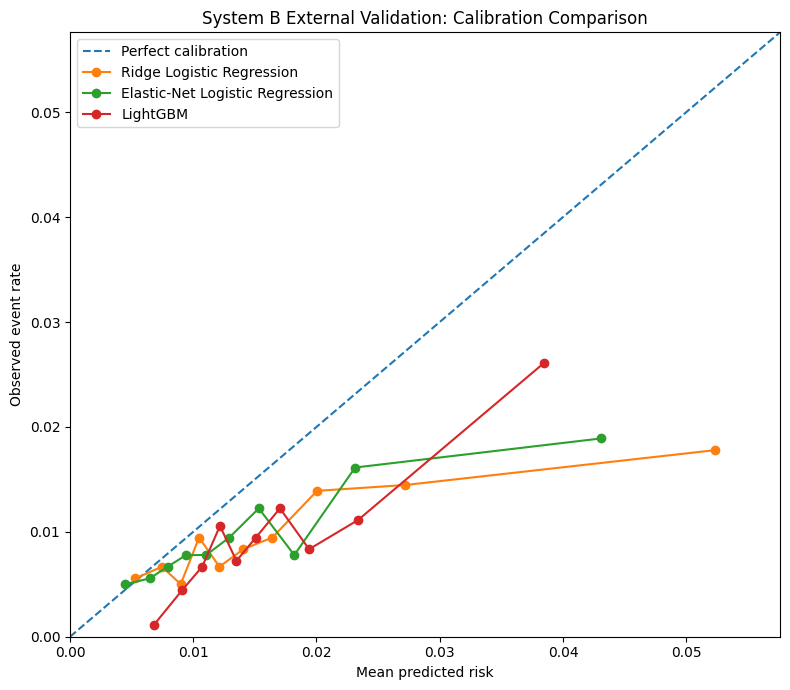

In [18]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(
    figsize=(8, 7)
)


maximum_risk = max(
    external_calibration_table[
        "mean_predicted_risk"
    ].max(),

    external_calibration_table[
        "observed_event_rate"
    ].max(),
)

plot_limit = maximum_risk * 1.10


ax.plot(
    [0, plot_limit],
    [0, plot_limit],
    linestyle="--",
    label="Perfect calibration",
)


for model_name in (
    external_model_probabilities
):
    model_table = (
        external_calibration_table.loc[
            external_calibration_table[
                "model"
            ] == model_name
        ]
    )

    ax.plot(
        model_table[
            "mean_predicted_risk"
        ],
        model_table[
            "observed_event_rate"
        ],
        marker="o",
        label=model_name,
    )


ax.set_xlim(
    0,
    plot_limit,
)

ax.set_ylim(
    0,
    plot_limit,
)

ax.set_xlabel(
    "Mean predicted risk"
)

ax.set_ylabel(
    "Observed event rate"
)

ax.set_title(
    "System B External Validation: "
    "Calibration Comparison"
)

ax.legend()

plt.tight_layout()
plt.show()

## 9. Freeze External-Validation Artifacts

Locked external validation in Health System B is complete.

The following artifacts are saved before any distribution-shift analysis
or recalibration is performed:

- the frozen System B patient-level feature matrix;
- original System A model predictions in System B;
- locked external-validation performance estimates;
- bootstrap confidence intervals;
- paired model comparisons;
- internal-to-external transportability summaries;
- external calibration deciles;
- the external calibration figure.

These predictions represent the unmodified System A models and must not
be overwritten by subsequent recalibration analyses.

In [19]:
PROCESSED_DIR = (
    ROOT
    / "data"
    / "processed"
)

PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


SYSTEM_B_FEATURE_PATH = (
    PROCESSED_DIR
    / "system_b_features.csv"
)


system_b_features.to_csv(
    SYSTEM_B_FEATURE_PATH,
    index=False,
)


print(
    f"Saved frozen System B feature matrix:\n"
    f"{SYSTEM_B_FEATURE_PATH.relative_to(ROOT)}"
)

Saved frozen System B feature matrix:
data/processed/system_b_features.csv


In [20]:
TABLE_DIR = (
    FROZEN_DIR
    / "tables"
)

PREDICTION_DIR = (
    FROZEN_DIR
    / "predictions"
)

FIGURE_DIR = (
    ROOT
    / "figures"
)


for directory in [
    TABLE_DIR,
    PREDICTION_DIR,
    FIGURE_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


system_b_external_predictions = pd.DataFrame(
    {
        "patient_id":
            system_b_features[
                "patient_id"
            ].to_numpy(),

        "outcome":
            y_b.to_numpy(),

        "ridge_probability":
            ridge_probability_b,

        "elastic_net_probability":
            elastic_net_probability_b,

        "lightgbm_probability":
            lightgbm_probability_b,
    }
)


assert len(
    system_b_external_predictions
) == 17_982

assert (
    system_b_external_predictions[
        "patient_id"
    ]
    .duplicated()
    .sum()
    == 0
)

assert int(
    system_b_external_predictions[
        "outcome"
    ].sum()
) == 175


SYSTEM_B_PREDICTION_PATH = (
    PREDICTION_DIR
    / "system_b_external_predictions.csv"
)


system_b_external_predictions.to_csv(
    SYSTEM_B_PREDICTION_PATH,
    index=False,
)


system_b_external_predictions.head()

,patient_id,outcome,ridge_probability,elastic_net_probability,lightgbm_probability
0,p100001,0,0.015237,0.016192,0.018262
1,p100002,0,0.012279,0.009944,0.015640
2,p100003,0,0.011213,0.011812,0.018156
3,p100004,0,0.015364,0.014984,0.012823
4,p100005,0,0.016577,0.013800,0.027945


In [21]:
system_b_cohort_summary.rename_axis(
    "metric"
).reset_index(
    name="value"
).to_csv(
    TABLE_DIR
    / "system_b_cohort_summary.csv",
    index=False,
)

external_prediction_summary.to_csv(
    TABLE_DIR
    / "system_b_prediction_summary.csv",
    index=False,
)

external_validation_summary.to_csv(
    TABLE_DIR
    / "system_b_external_validation_summary.csv",
    index=False,
)

external_confidence_intervals.to_csv(
    TABLE_DIR
    / "system_b_external_confidence_intervals.csv",
    index=False,
)

paired_external_comparison.to_csv(
    TABLE_DIR
    / "system_b_paired_model_comparison.csv",
    index=False,
)

transportability_summary.to_csv(
    TABLE_DIR
    / "system_a_to_b_transportability_summary.csv",
    index=False,
)

external_calibration_table.to_csv(
    TABLE_DIR
    / "system_b_calibration_deciles.csv",
    index=False,
)

print(
    "Saved locked System B external-validation tables."
)


Saved locked System B external-validation tables.


In [22]:
EXTERNAL_CALIBRATION_FIGURE_PATH = (
    FIGURE_DIR
    / "system_b_external_calibration.png"
)


fig.savefig(
    EXTERNAL_CALIBRATION_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)


print(
    f"Saved calibration figure:\n"
    f"{EXTERNAL_CALIBRATION_FIGURE_PATH.relative_to(ROOT)}"
)

Saved calibration figure:
figures/system_b_external_calibration.png


In [23]:
required_external_artifacts = [
    SYSTEM_B_FEATURE_PATH,
    SYSTEM_B_PREDICTION_PATH,

    TABLE_DIR
    / "system_b_cohort_summary.csv",

    TABLE_DIR
    / "system_b_prediction_summary.csv",

    TABLE_DIR
    / "system_b_external_validation_summary.csv",

    TABLE_DIR
    / "system_b_external_confidence_intervals.csv",

    TABLE_DIR
    / "system_b_paired_model_comparison.csv",

    TABLE_DIR
    / "system_a_to_b_transportability_summary.csv",

    TABLE_DIR
    / "system_b_calibration_deciles.csv",

    EXTERNAL_CALIBRATION_FIGURE_PATH,
]


for artifact_path in (
    required_external_artifacts
):
    assert artifact_path.exists()

    assert (
        artifact_path.stat().st_size
        > 0
    )


reloaded_predictions = pd.read_csv(
    SYSTEM_B_PREDICTION_PATH
)

assert len(
    reloaded_predictions
) == 17_982

assert int(
    reloaded_predictions[
        "outcome"
    ].sum()
) == 175


np.testing.assert_allclose(
    reloaded_predictions[
        "ridge_probability"
    ],
    ridge_probability_b,
)

np.testing.assert_allclose(
    reloaded_predictions[
        "elastic_net_probability"
    ],
    elastic_net_probability_b,
)

np.testing.assert_allclose(
    reloaded_predictions[
        "lightgbm_probability"
    ],
    lightgbm_probability_b,
)


print(
    "System B external-validation "
    "artifact integrity check passed."
)

System B external-validation artifact integrity check passed.


## 10. Final Status

**Locked Health System B external validation is complete.**

The frozen System A models were applied without modification to 17,982
eligible System B patients, including 175 incident sepsis events.

The principal external-validation findings are:

- System B has substantially lower baseline event prevalence than
  System A;
- all three System A models systematically overpredict absolute risk in
  System B;
- discrimination deteriorates after transport for all three models;
- Ridge and Elastic-Net logistic regression additionally show marked
  deterioration in calibration slope;
- LightGBM retains stronger discrimination and substantially more stable
  relative-risk calibration, although its absolute risk remains
  systematically overestimated.

No recalibration has yet been performed.

The next stage investigates distributional, missingness, and measurement
shifts between Health Systems A and B.